# ENGR 1330 – Computational Thinking and Data Science

## Traffic Volume Predictor Final Project - Background

Traffic congestion is a rising concern globally, escpecially for big cities. There can be numerous factors playing role determining traffic volume, and they are worth researching to understand and predict the traffic pattern at specific locations. Among different factors, time is a critical determinant of traffic congestion. Everywhere, there are particualr times in a day when number of vehicles passing through a crossroad is far higher than other times.   

Here we have a dataset that records traffic volume every hours at 3 different junctions in a city, for a period of 1 year and 8 months. You will find a way to predict the traffic at any time of the day at any junction.  

## Objective(s):
- Literature scan on traffic flow analysis, and necessity of investigating temporal pattern of traffic flow
- Analyse an existing traffic volume database and build a data model to predict the traffic 
- Build an interface to allow users to enter date and time and return an estimated traffic volume and an assessment of the uncertainty in the estimate
- Build an interface to allow users to add observations to the underlying database, and automatically update the Data Model to incorporate the new observations

## Tasks: 

**Literature Research:**

Do some background study on temporal traffic behavior and its significance. Here are some good ones to begin with:
1. https://onlinelibrary.wiley.com/doi/epdf/10.1111/0885-9507.00200
2. https://proceedings.esri.com/library/userconf/proc08/papers/papers/pap_1613.pdf
3. https://www.sciencedirect.com/science/article/pii/S1352231015001661?casa_token=89oxxn8VJ2gAAAAA:QMwqati_EyuC_BbzS8IRDOJ1kSev-kcHcUk5NTVwfH4RP4G397ZI-IhfkMK6sYJF2jm9YTI0QA



**Exploratory Data Analysis**
- Describe the data. Include statistical and visual description of the data.
- Create pairplots for all the appropriate columns and check for correlation coefficients, make comments on your observation 

**Model Building**
- For each of the 3 junctions, you should come up with a model to predict the traffic volume at any time of  a day. To find a best model, test at least 2 different models for each junction, and compare accuracy. For each junction:
     - you should  determine which input strongly affects the traffic flow. 
     - Build 2 models using the input factor for each junction. You can adopt any 2 different mathematical model (e.g. linear, polynomial etc)
     - Assess data model quality (decide which model is best) including appropriate metric
- Build the input data interface for using the model
- Using the model for each zone, determine projected traffic volume for each junction, and an assessment of uncertainty for the following times of a day: 2 am, 6 am, 3 pm and 7 pm. 
               
       
**Documentation**
- Training and Project management video on how to use your tool, and demonstrate the tool(s) as they are run
- Interim report (see deliverables below); this document must be rendered as a .pdf, Word template is in BlackBoard.
- Final ipynb file (see deliverables below)

## Deliverables:

#### Part 1 Interim Report (due May 5):
A report that briefly describes the project. Use the Interim Report Template on BlackBoard. 
- Break down each task into manageable subtasks and describe how you intend to solve the subtasks and how you will test each task. (Perhaps make a simple Gantt Chart) or list of meeting times. 
- Address the responsibilities of each team member for tasks completed and tasks to be completed until the end of the semester. (Perhaps make explicit subtask assignments)  

#### Part 2 Final Report (due May 10):
- A well-documented JupyterLab (using a python kernel), use markdown cells and commenting for explanations and text. 
- A how-to video demonstrating performance and description of problems that you were not able to solve and also talk about project management such as who did what. Active participation of every single group member is mandatory in the presentation. 
- A final peer evaluation report, where each group member should rate the participation and contribution of the other members.

**Above items can reside in a single video; but structure the video into the two parts; use an obvious transition when moving from "how to ..." into the project management portion.**  Keep the total video length to less than 10 minutes; submit as an *unlisted* YouTube video, and just supply the link (someone on each team is likely to have a YouTube creator account).  Keep in mind a 10 minute video can approach 100MB file size before compression, so it won't upload to Blackboard and cannot be emailed.

# 1. Import Libraries

In [2]:
#Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import seaborn as sns

# 2. Load Dataset

In [3]:
#Load Dataset
df = pd.read_csv("Traffic Data.csv")
df.head() #Display first 5 rows

,ID,Year,Month,Hour,Date,Junction,Vehicles
0,20151101001,2015,11,0,1,1,15
1,20151101011,2015,11,1,1,1,13
2,20151101021,2015,11,2,1,1,10
3,20151101031,2015,11,3,1,1,7
4,20151101041,2015,11,4,1,1,9


# 3. Data Pre-Processing

In [4]:
#Data Pre-Processing

# Combine Date features into datetime-like structure (optional but useful)
df["DateTime"] = pd.to_datetime(df["Year"].astype(str) + "-" +
                                 df["Month"].astype(str) + "-" +
                                 df["Date"].astype(str) + " " +
                                 df["Hour"].astype(str) + ":00:00")

# Extract useful time features
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df.head()

,ID,Year,Month,Hour,Date,Junction,Vehicles,DateTime,DayOfWeek,IsWeekend
0,20151101001,2015,11,0,1,1,15,2015-11-01 00:00:00,6,1
1,20151101011,2015,11,1,1,1,13,2015-11-01 01:00:00,6,1
2,20151101021,2015,11,2,1,1,10,2015-11-01 02:00:00,6,1
3,20151101031,2015,11,3,1,1,7,2015-11-01 03:00:00,6,1
4,20151101041,2015,11,4,1,1,9,2015-11-01 04:00:00,6,1


# 4. Exploratory Data Analysis (EDA)

## 4.1 Statistical Summary

In [5]:
#Exploratory Data Analysis (EDA)

df.describe()

,ID,Year,Month,Hour,Date,Junction,Vehicles,DateTime,DayOfWeek,IsWeekend
count,4.377600e+04,43776.000000,43776.000000,43776.000000,43776.000000,43776.000000,43776.000000,43776,43776.000000,43776.000000
mean,2.016260e+10,2016.197368,6.120066,11.500000,15.710526,2.000000,24.333379,2016-08-30 23:30:00,2.996711,0.284539
min,2.015110e+10,2015.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2015-11-01 00:00:00,0.000000,0.000000
25%,2.016038e+10,2016.000000,3.000000,5.750000,8.000000,1.000000,10.000000,2016-03-31 23:45:00,1.000000,0.000000
50%,2.016083e+10,2016.000000,6.000000,11.500000,16.000000,2.000000,17.000000,2016-08-30 23:30:00,3.000000,0.000000
75%,2.017013e+10,2017.000000,10.000000,17.250000,23.000000,3.000000,32.000000,2017-01-29 23:15:00,5.000000,1.000000
max,2.017063e+10,2017.000000,12.000000,23.000000,31.000000,3.000000,180.000000,2017-06-30 23:00:00,6.000000,1.000000
std,5.779462e+06,0.599233,3.619760,6.922266,8.788835,0.816506,21.112090,NaN,2.000020,0.451200


## 4.2 Missing Values

In [6]:
#Check For Missing Values

print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
ID           0
Year         0
Month        0
Hour         0
Date         0
Junction     0
Vehicles     0
DateTime     0
DayOfWeek    0
IsWeekend    0
dtype: int64


## 4.3 Traffic Distribution by Junction

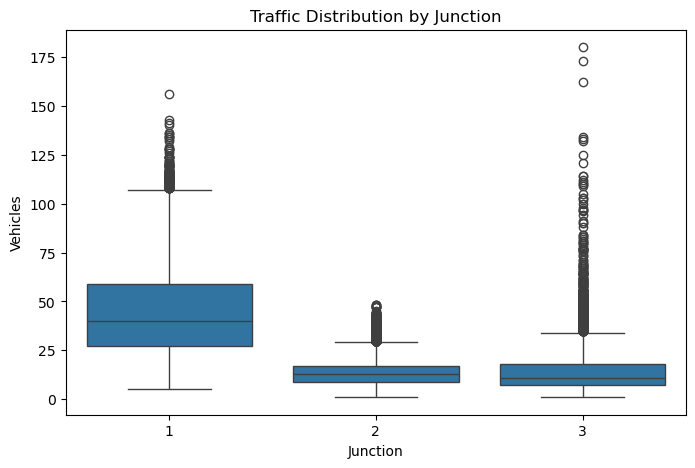

In [7]:
#Traffic Distribution by Junction

plt.figure(figsize=(8,5))
sns.boxplot(x="Junction", y="Vehicles", data=df)
plt.title("Traffic Distribution by Junction")
plt.show()

This boxplot reveals that while Junction 1 serves as the primary high-traffic artery, Junction 3 is prone to the most extreme traffic spikes, despite having a low median volume. Junction 2 remains the most predictable and least congested route.

## 4.4 Average Traffic by Hour

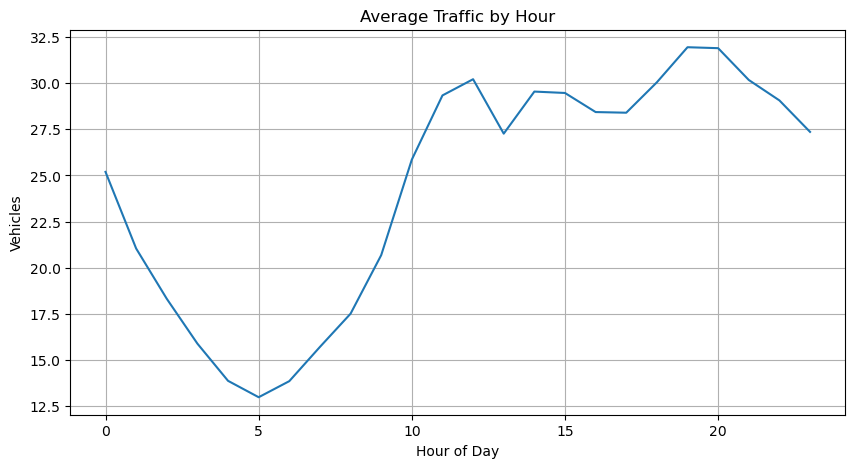

In [8]:
#Average Traffic By Hour
hourly = df.groupby("Hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly.values)
plt.title("Average Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

The hourly distribution reveals a clear diurnal cycle, where traffic volume reaches its daily minimum at 5am and climbs steadily to a primary evening peak between 7pm and 8pm. The sustained high volume throughout the afternoon suggests a mix of commercial and recreational transit beyond just standard commute hours.

## 4.5 Correlation Matrix

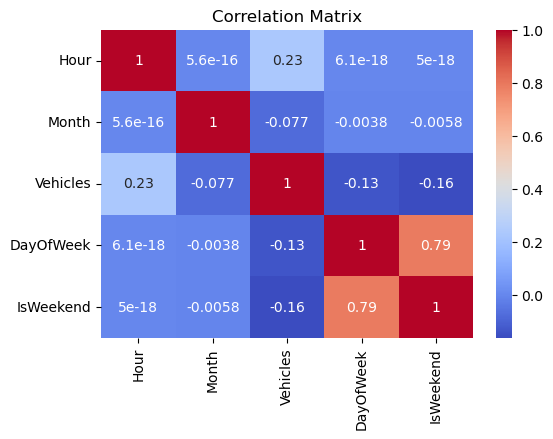

In [9]:
#Correlation Matrix

plt.figure(figsize=(6,4))
sns.heatmap(df[["Hour","Month","Vehicles","DayOfWeek","IsWeekend"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The above correlation matrix identifies "Hour" as the most influential factor on traffic volume. Interestingly, there is a slight negative correlation with "IsWeekend", indicating that weekday commutes likely drive the bulk of the traffic. Most other variables show negligible linear relationships, suggesting traffic patterns are more dependent on daily cycles than seasonal changes.

## 4.6 Pairplots

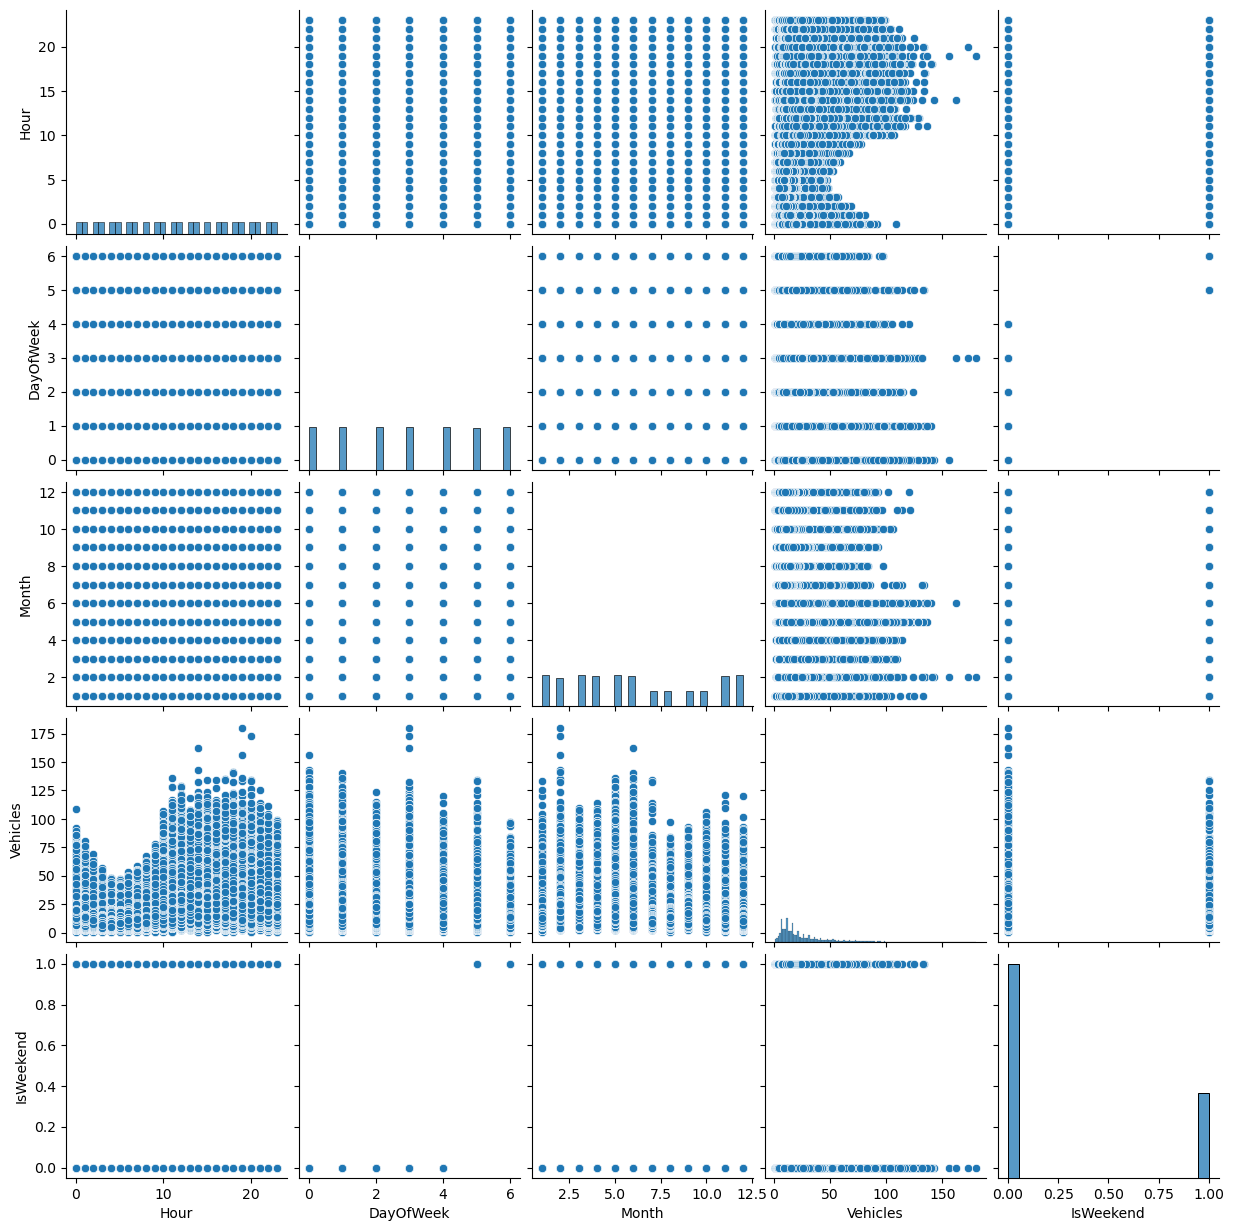

In [10]:
#Pairplots

sns.pairplot(
    df[[
        "Hour",
        "DayOfWeek",
        "Month",
        "Vehicles",
        "IsWeekend"
    ]]
)

plt.show()

The pairplot confirms that "Vehicles" is right-skewed, with most observations falling into lower volume ranges. The scatter plots against "Hour" reveal a high-density cluster during daylight hours, while the striped distributions for "DayOfWeek" and "IsWeekend" highlight the reduction in peak traffic during the weekend period compared to the work week.

# 5. Feature Analysis

In [27]:
#Feature Analysis

correlations = df.corr(numeric_only=True)["Vehicles"].sort_values(
    ascending=False
)

print("\nCORRELATION WITH VEHICLES")
print(correlations)


CORRELATION WITH VEHICLES
Vehicles     1.000000
ID           0.351490
Year         0.343494
Hour         0.230199
Date         0.029406
Month       -0.076837
DayOfWeek   -0.133854
IsWeekend   -0.160073
Junction    -0.606356
RecordID          NaN
Name: Vehicles, dtype: float64


"Junction" appears to be the primary driver of traffic volume, with a strong negative correlation indicating that lower-numbered junctions handle significantly more vehicles. Additionally, the positive correlation with "Year" suggests an upward trend in overall traffic over the dataset's duration, while "Hour" remains the most significant periodic predictor. This means that traffic patterns reliably repeat every 24 hours, making the time of day the best way to predict routine congestion.

# 6. Model Building

## 6.1 Model Training Function

In [12]:
#Model Training Function
def train_models(junction_data):
    #Input Features
    X = junction_data[[
        "Hour",
        "DayOfWeek",
        "IsWeekend"
    ]]

    y = junction_data["Vehicles"]

    #Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    #Model 1 - Linear Regression:
    lin_model = LinearRegression()

    lin_model.fit(X_train, y_train)

    lin_pred = lin_model.predict(X_test)

    #Model 2 - Polynomial Regression:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=3),
        LinearRegression()
    )

    poly_model.fit(X_train, y_train)

    poly_pred = poly_model.predict(X_test)

    #Model Evaluation:
    def evaluate(name, y_true, y_pred):

        mae = mean_absolute_error(y_true, y_pred)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        r2 = r2_score(y_true, y_pred)

        print(f"\n{name}")

        print(f"MAE  : {mae:.2f}")
        print(f"RMSE : {rmse:.2f}")
        print(f"R²   : {r2:.3f}")

    print("\nModel Performance")

    evaluate(
        "Linear Regression",
        y_test,
        lin_pred
    )

    evaluate(
        "Polynomial Regression",
        y_test,
        poly_pred
    )

    #Return Models
    return (
        lin_model,
        poly_model,
        X_train,
        y_train
    )

## 6.2 Model Training for Each Junction

In [13]:
models = {}

for j in df["Junction"].unique():
    print(f"\n===== JUNCTION {j} =====")
    data_j = df[df["Junction"] == j]
    models[j] = train_models(data_j)


===== JUNCTION 1 =====

Model Performance

Linear Regression
MAE  : 15.99
RMSE : 19.77
R²   : 0.251

Polynomial Regression
MAE  : 15.12
RMSE : 18.64
R²   : 0.335

===== JUNCTION 2 =====

Model Performance

Linear Regression
MAE  : 4.94
RMSE : 6.56
R²   : 0.197

Polynomial Regression
MAE  : 4.70
RMSE : 6.25
R²   : 0.270

===== JUNCTION 3 =====

Model Performance

Linear Regression
MAE  : 6.32
RMSE : 9.66
R²   : 0.153

Polynomial Regression
MAE  : 5.80
RMSE : 9.24
R²   : 0.225


# 7. Model Evaluation

Across all three junctions, Polynomial Regression provided a superior fit, better capturing the non-linear peaks of daily traffic cycles. Junction 2 yielded the most precise predictions with the lowest absolute error, while Junction 3's performance was significantly impacted by its frequent traffic surges, evidenced by the high gap between its MAE and RMSE scores.

# 8. Uncertainty Analysis

In [14]:
#Traffic Prediction with Uncertainty
def prediction_with_uncertainty(
    model,
    X_train,
    y_train,
    hour,
    dayofweek=0,
    isweekend=0
):

    #Predict training data
    preds = model.predict(X_train)

    #Residuals
    residuals = y_train - preds

    #Standard deviation of residuals
    uncertainty = np.std(residuals)

    #Create input dataframe
    input_data = pd.DataFrame({
        "Hour": [hour],
        "DayOfWeek": [dayofweek],
        "IsWeekend": [isweekend]
    })

    prediction = model.predict(input_data)[0]

    return prediction, uncertainty

# 9. Traffic Predictions

In [28]:
#Time Predictions
times = [2, 6, 15, 19]

for j in df["Junction"].unique():
    print(f"\n===== JUNCTION {j} PREDICTIONS =====")

    data_j = df[df["Junction"] == j]
    _, poly_model, X_train, y_train = models[j]

    for t in times:
        pred, uncertainty = prediction_with_uncertainty(
            poly_model,
            X_train,
            y_train,
            t
        )

        print(
            f"Hour {t}: "
            f"{pred:.2f} ± {uncertainty:.2f} vehicles"
        )


===== JUNCTION 1 PREDICTIONS =====
Hour 2: 29.87 ± 18.71 vehicles
Hour 6: 33.23 ± 18.71 vehicles
Hour 15: 64.42 ± 18.71 vehicles
Hour 19: 68.37 ± 18.71 vehicles

===== JUNCTION 2 PREDICTIONS =====
Hour 2: 10.88 ± 6.30 vehicles
Hour 6: 10.27 ± 6.30 vehicles
Hour 15: 18.51 ± 6.30 vehicles
Hour 19: 20.64 ± 6.30 vehicles

===== JUNCTION 3 PREDICTIONS =====
Hour 2: 8.73 ± 9.34 vehicles
Hour 6: 8.75 ± 9.34 vehicles
Hour 15: 18.40 ± 9.34 vehicles
Hour 19: 19.04 ± 9.34 vehicles


# 10. User Input Interface

In [16]:
#User Input Interface
def predict_traffic():

    junction = int(input("Enter Junction (1-3): "))

    hour = int(input("Enter Hour (0-23): "))

    day = int(input(
        "Enter DayOfWeek "
        "(0 = Monday ... 6 = Sunday): "
    ))

    weekend = int(input(
        "Is it weekend? (0 = No, 1 = Yes): "
    ))

    _, model, X_train, y_train = models[junction]

    pred, uncertainty = prediction_with_uncertainty(
        model,
        X_train,
        y_train,
        hour,
        day,
        weekend
    )

    print("\nPREDICTION RESULT")

    print(
        f"Predicted traffic volume: "
        f"{pred:.2f} vehicles"
    )

    print(
        f"Estimated uncertainty: "
        f"± {uncertainty:.2f} vehicles"
    )

In [17]:
predict_traffic()

Enter Junction (1-3):  2
Enter Hour (0-23):  10
Enter DayOfWeek (0 = Monday ... 6 = Sunday):  3
Is it weekend? (0 = No, 1 = Yes):  0



PREDICTION RESULT
Predicted traffic volume: 14.07 vehicles
Estimated uncertainty: ± 6.30 vehicles


# 11. Observation Interface

In [24]:
#Add New Observation
def add_observation():
    print("ENTER NEW TRAFFIC OBSERVATION")

    junction = int(input("Enter Junction (1-3): "))
    year = int(input("Enter Year (e.g: 2017): "))
    month = int(input("Enter Month (1-12): "))
    date = int(input("Enter Day of Month (1-31): "))
    hour = int(input("Enter Hour (0-23): "))
    vehicles = int(input("Enter Vehicle Count: "))

    #Create Record ID
    record_id = int(
        f"{year}"
        f"{month:02d}"
        f"{date:02d}"
        f"{hour:02d}"
        f"{junction}"
    )

    #Create new row
    new_row = pd.DataFrame({
        "RecordID": [record_id],
        "Year": [year],
        "Month": [month],
        "Hour": [hour],
        "Date": [date],
        "Junction": [junction],
        "Vehicles": [vehicles]
    })

    #Add to dataset
    global df

    df = pd.concat([df, new_row], ignore_index=True)

    #Recreate DateTime column
    df["DateTime"] = pd.to_datetime(
        df["Year"].astype(str) + "-" +
        df["Month"].astype(str) + "-" +
        df["Date"].astype(str) + " " +
        df["Hour"].astype(str) + ":00:00"
    )

    #Recreate derived features
    df["DayOfWeek"] = df["DateTime"].dt.dayofweek

    df["IsWeekend"] = (
        df["DayOfWeek"].isin([5, 6]).astype(int)
    )

    #Retrain models
    for j in df["Junction"].unique():
        data_j = df[df["Junction"] == j]
        models[j] = train_models(data_j)

    print("\nObservation added successfully.")
    print("\nModels retrained.")

In [25]:
add_observation()

ENTER NEW TRAFFIC OBSERVATION


Enter Junction (1-3):  1
Enter Year (e.g: 2017):  2018
Enter Month (1-12):  5
Enter Day of Month (1-31):  15
Enter Hour (0-23):  21
Enter Vehicle Count:  4



Model Performance

Linear Regression
MAE  : 15.95
RMSE : 19.76
R²   : 0.249

Polynomial Regression
MAE  : 15.06
RMSE : 18.60
R²   : 0.335

Model Performance

Linear Regression
MAE  : 4.94
RMSE : 6.56
R²   : 0.197

Polynomial Regression
MAE  : 4.70
RMSE : 6.25
R²   : 0.270

Model Performance

Linear Regression
MAE  : 6.32
RMSE : 9.66
R²   : 0.153

Polynomial Regression
MAE  : 5.80
RMSE : 9.24
R²   : 0.225

Observation added successfully.

Models retrained.


# 12. Model Visualization

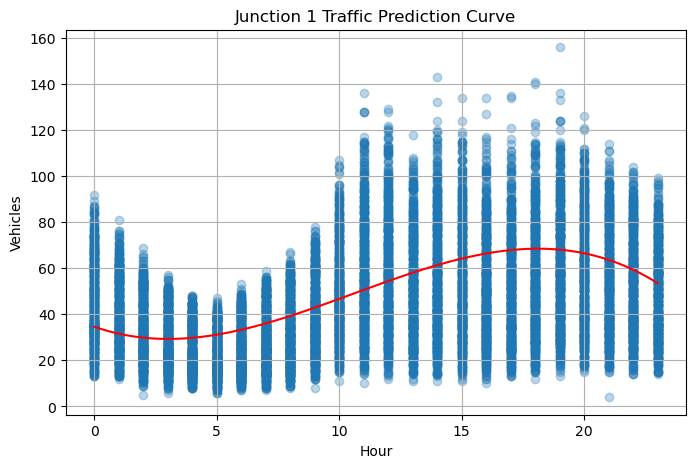

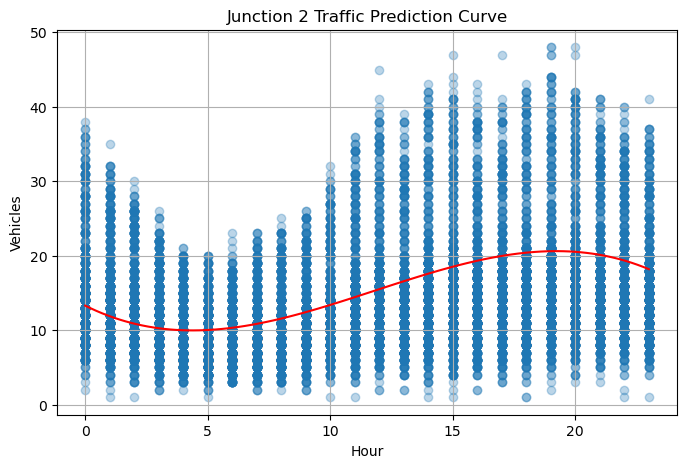

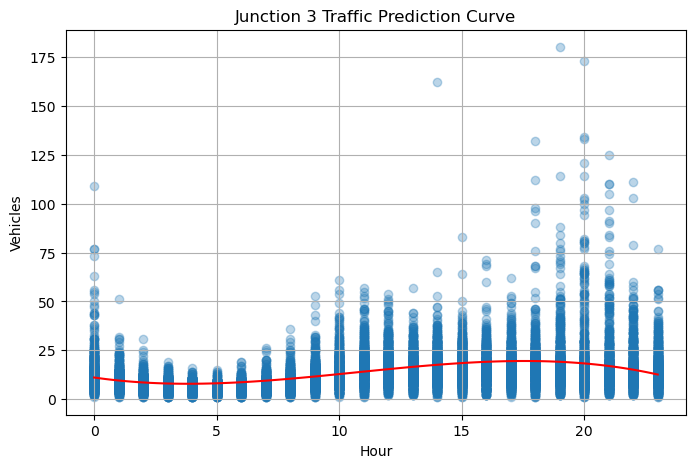

In [26]:
#Visualize Model Fit For Each Junction
for j in df["Junction"].unique():

    data_j = df[df["Junction"] == j]

    X = data_j[[
        "Hour",
        "DayOfWeek",
        "IsWeekend"
    ]]

    y = data_j["Vehicles"]

    model = make_pipeline(
        PolynomialFeatures(3),
        LinearRegression()
    )

    model.fit(X, y)

    #Generate smooth hour values
    hour_range = np.linspace(0, 23, 100)

    #Hold other variables constant
    graph_data = pd.DataFrame({
        "Hour": hour_range,
        "DayOfWeek": np.zeros(100),
        "IsWeekend": np.zeros(100)
    })

    preds = model.predict(graph_data)

    #Plot:abs
    plt.figure(figsize=(8, 5))

    plt.scatter(
        data_j["Hour"],
        y,
        alpha=0.3
    )

    plt.plot(
        hour_range,
        preds,
        color="red"
    )

    plt.title(f"Junction {j} Traffic Prediction Curve")
    plt.xlabel("Hour")
    plt.ylabel("Vehicles")
    plt.grid()
    plt.show()

The above prediction curves visualize the Polynomial Regression model's fit against the actual observed data. The red regression line effectively tracks the non-linear "heartbeat" of daily traffic, confirming that while the model accurately predicts baseline traffic trends, it deliberately minimizes the influence of extreme, infrequent outliers to maintain overall predictive stability.

# 13. Conclusion

Ultimately, this project demonstrates that urban traffic follows a predictable, periodic cycle. Based on the calculated R² values, the model captures approximately 25-33% of the variance in traffic volume using only time-based features. While the Polynomial model provides a reliable baseline for daily planning, the high residual variance suggests that future iterations could be improved by integrating external variables like weather conditions or public holiday schedules.